# Forecast example

This notebook introduces the basic workflow using the `py_online_forecast` package.

It covers:
- Data handling with the `fc` accessor,
- feature engineering using transformations,
- minimal forecasting example using `WLS`,
- online forecasting using `ForecastModel`,
- multi-horizon forecasting using `ForecastEnsemble`,
- transforms and sources,
- hyperparameter optimization.

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize

from py_online_forecast import *
from py_online_forecast.datasets import sample_data
from py_online_forecast.forecast_tools import ForecastFormat, Subset


## Data

This example uses simulated sample data from `py_online_forecast.datasets.sample_data`.

The sample data is a pandas DataFrame following the "forecast-matrix" format. This requires that
- the columns are a two level MultiIndex of feature names and forecast horizons,
- the index is monotonically increasing and evenly spaced.

The feature names can be freely chosen, whilst the forecast horizons should be a non-negative integer. A forecast horizon of zero corresponds to "now" and may be used for observed values.

### The `fc` accessor

To support the forecast format, a custom `pandas` accessor with name `fc` can be used. The `fc` accessor provides convenience methods for working with forecast-matrix data. We begin by subsetting the data based on the horizons,

In [34]:
data = sample_data.fc.subset(horizons=(0, 1, 2, 4), end_index=200)
data.head()


Variable                energy      Taobs         Ta                      
Horizon                      0          0          1          2          4
2130-01-01 00:00:00  51.531885  15.668848  14.732529  18.112065  18.771499
2130-01-01 01:00:00  50.988901  16.327964  18.274593  18.991357  18.759832
2130-01-01 02:00:00  50.479686  18.319822  15.477482  22.260192  19.841512
2130-01-01 03:00:00  50.420587  20.230697  15.111263  20.589555  19.198036
2130-01-01 04:00:00  56.704199  19.268107  17.443227  20.205426  18.872228

The `fc` accessor provides several other methods, a few examples are
- lagging forecast columns to align them with observations,
- subsetting by variable name and horizon,
- converting nearly compatible DataFrames into forecast-matrix format.


In [35]:
lagged = data.fc.lag()
subset_data = data.fc.subset("Ta", "Taobs", horizons=(0, 1, 2))
converted = data.fc.convert()

lagged.head()


Variable                energy      Taobs         Ta                      
Horizon                      0          0          1          2          4
2130-01-01 00:00:00  51.531885  15.668848        NaN        NaN        NaN
2130-01-01 01:00:00  50.988901  16.327964  14.732529        NaN        NaN
2130-01-01 02:00:00  50.479686  18.319822  18.274593  18.112065        NaN
2130-01-01 03:00:00  50.420587  20.230697  15.477482  18.991357        NaN
2130-01-01 04:00:00  56.704199  19.268107  15.111263  22.260192  18.771499

In [36]:
subset_data.head()

Variable                 Taobs         Ta           
Horizon                      0          1          2
2130-01-01 00:00:00  15.668848  14.732529  18.112065
2130-01-01 01:00:00  16.327964  18.274593  18.991357
2130-01-01 02:00:00  18.319822  15.477482  22.260192
2130-01-01 03:00:00  20.230697  15.111263  20.589555
2130-01-01 04:00:00  19.268107  17.443227  20.205426

## Sources & Transformations
The `py_online_forecast` package is built around `Source` and `Transformation` objects. A `Source` instance is a placeholder for data, and a `Transformation` instance is a source that has methods for processing data. Most transformations require other sources as inputs and are used to define data transformations for feature engineering. When data arrives, they should be matched to sources (using a `dict`), after which all transformations may be resolved. 

In [37]:
raw_data = Source("Raw data")

transformed_data = raw_data*10

raw_data_value = np.array([1, 2, 3])

transformed_data({raw_data: raw_data_value})

array([10, 20, 30])

If no source is specified for a piece of data, it will be matched to `DEFAULT_SOURCE`. With this, we can simplify the above to

In [38]:
transformed_data = DEFAULT_SOURCE*10
transformed_data(raw_data_value)

array([10, 20, 30])

For basic usage, it is convenient to build our data pipeline from this source. For example, we may want to make 1-step forecasts of the `energy` variable using an intercept, the observed temperature `Taobs` and the 1-horizon forecasts `Ta`.

In [39]:
energy = DEFAULT_SOURCE[["energy"]]
const = One()
taobs = DEFAULT_SOURCE[["Taobs"]]
ta = Subset(DEFAULT_SOURCE, "Ta", horizons=(1,))

In the above, `energy`, `const`, `taobs` and `ta` are all transformations. Except for `const`, they are all explicitly defined from a source (`DEFAULT_SOURCE`). Behind the scenes `One` also uses an input source, but tacitly assumes it to be the `DEFAULT_SOURCE`. The `Subset` transformation assumes input values to be of forecast-matrix type, and selects variables and horizons.

To see the output of the transformations, we can call them on the data, e.g.

In [40]:
energy(data)


Variable,energy
Horizon,0
2130-01-01 00:00:00,51.531885
2130-01-01 01:00:00,50.988901
2130-01-01 02:00:00,50.479686
2130-01-01 03:00:00,50.420587
2130-01-01 04:00:00,56.704199
...,...
2130-01-09 03:00:00,49.960682
2130-01-09 04:00:00,45.807139
2130-01-09 05:00:00,41.252420


In [41]:
const(data)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

To filter out noise, we may compose new transformations using a low-pass filter. The LowPass transformation acts on a single source as,

In [42]:
lp_Taobs = LowPass(taobs, alpha=0.7)
lp_Ta = LowPass(ta, alpha=0.9)

When transformations are instantiated, some inputs may be sources, whilst others are "fixed" parameters. As a design principle, transforms should not change when they are applied to data, e.g. by calling,

In [43]:
lp_Ta(data)


array([[14.73252902],
       [15.08673546],
       [15.12581011],
       [15.12435539],
       [15.35624258],
       [15.56804962],
       [15.6201329 ],
       [15.71450542],
       [15.82513629],
       [15.93598984],
       [16.05130706],
       [16.1547127 ],
       [16.23343967],
       [16.26894976],
       [16.12230671],
       [15.94614044],
       [15.85527247],
       [15.6858657 ],
       [15.54162711],
       [15.38306027],
       [15.25433397],
       [15.0038216 ],
       [14.78348837],
       [14.72742177],
       [14.68764903],
       [14.72506837],
       [14.87019004],
       [15.13905267],
       [15.30309212],
       [15.47987049],
       [15.71348377],
       [16.07431685],
       [16.48721419],
       [16.76366883],
       [17.05318245],
       [17.23303922],
       [17.19678969],
       [17.01485724],
       [16.94458308],
       [16.80503379],
       [16.4592888 ],
       [15.99876105],
       [15.59505293],
       [15.09556266],
       [14.61636251],
       [14

With an important exception (see below), this should not change the `lp_Ta` object. Fixed parameters may instead be changed using the specific interface of the transformation, e.g. for LowPass transformations we can change the smoothing parameter `alpha` by overwriting it,

In [44]:
lp_Ta.alpha = 0.8

Some transformations are not memory-less, i.e. they require some state or old data to continue where they left of. An example of this is the `LowPass` filter, which requires the previous value of the input time series. In an online setting, data cannot be processed in batch, and handling of such "memory" states is important. Transformations can return this memory state along with the output by using `return_recursion_pars`,

In [45]:
lp_Ta(data, return_recursion_pars = True)

(array([[14.73252902],
        [15.44094189],
        [15.44824991],
        [15.3808525 ],
        [15.79332747],
        [16.12952456],
        [16.12139615],
        [16.20988852],
        [16.33207365],
        [16.45239327],
        [16.57974704],
        [16.68087031],
        [16.73309273],
        [16.70418229],
        [16.32384969],
        [15.93120855],
        [15.75245899],
        [15.43420815],
        [15.19606248],
        [14.94804172],
        [14.77759283],
        [14.37191633],
        [14.05763092],
        [14.09066921],
        [14.13847424],
        [14.32314788],
        [14.69377531],
        [15.26678353],
        [15.56931626],
        [15.86962816],
        [16.25890319],
        [16.87148546],
        [17.53784642],
        [17.88062925],
        [18.23626441],
        [18.35936156],
        [18.06159802],
        [17.52477147],
        [17.28224029],
        [16.93561028],
        [16.218005  ],
        [15.34520626],
        [14.66850097],
        [13

This information can then be passed to new calls of the transformation in order to resume computation from the old state. To make this more convenient, we may instead use the `track_state` flag, making the transformation handle the memory state and automatically use it in future calls, e.g.,

In [46]:
lp_Ta(data, track_state = True)
lp_Ta.recursion_pars

{Subset(['Ta'], horizons=(1,)): [False, False, True, False, False],
 ToArray: None,
 LowPass: array([15.40295399])}

> **Note:** If a transformation is called again **without** `track_state=True`, any stored state will not be used, nor will it be overwritten.

### Transformation shorthands
New sources can be created by composing transforms (e.g. instantiating `LowPass` on `taobs`), or by using common arithmetic operators or indexing, e.g.,


In [47]:
lp_square = lp_Ta**2
sum_transform = (lp_Ta + lp_square)[:10]
sum_transform(data)

array([[231.77994042],
       [253.86362847],
       [254.09667521],
       [251.95147616],
       [265.22252002],
       [276.29108723],
       [276.02080983],
       [278.97037442],
       [283.06870345],
       [287.13363761]])

## Basic prediction
The goal in this section is to forecast the `energy` variable using the ambient temperature observation and forecast transformations defined previously. To do so, we first form a design matrix for a weighted-least-squares type problem,

In [48]:
X = DesignMatrix(const, lp_Taobs, lp_Ta)

We can then define a prediction model using the `WLS` transformation,

In [49]:
pred = WLS(X, energy, horizon=1)

Calling the prediction on the data fits the model and returns predictions. With `track_state=True`, recursive state such as fitted WLS parameters is stored and can be inspected afterwards.

In [50]:
result = pred(data, track_state=True)
pred.predictor


array([[53.97516386],
       [-0.85765934],
       [ 0.67845426]])

For convenient use with forecast-matrix data, the output can be wrapped in `ForecastFormat`.


/tmp/ipykernel_13879/2240140727.py:7: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(data.index, data["energy"], label="Observations")


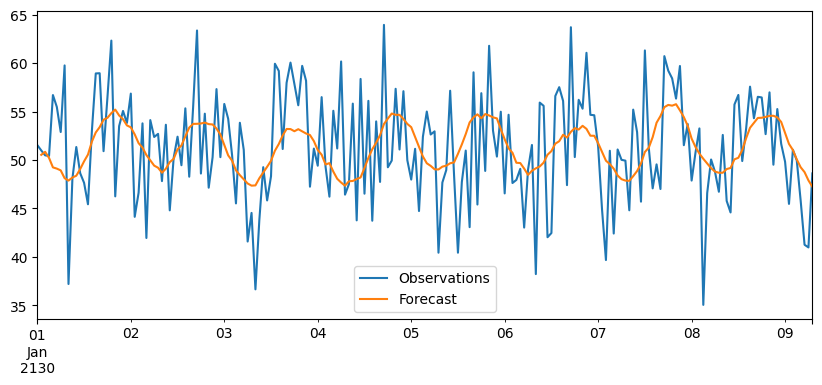

In [51]:
pred.set_format(ForecastFormat)
result = pred(data, track_state=False)

fig, ax = plt.subplots(figsize=(10, 4))
data.plot(y="energy", ax=ax)
result["mean"].fc.lag().plot(ax=ax)
ax.plot(data.index, data["energy"], label="Observations")
plt.legend(["Observations", "Forecast"])
plt.show()


As a simple check, compare the fitted coefficients with a direct NumPy least-squares estimate.


In [52]:
beta_ols = pred.predictor

pred.reset_state()
X_data = pred.X(data)
X_train_data = X_data[:-1]
Y_data = pred.Y(data)

beta_np = np.linalg.lstsq(X_train_data, Y_data.to_numpy()[1:], rcond=None)[0]

print(f"Model parameters from OLS model: {beta_ols}")
print(f"Model parameters from numpy lstsq: {beta_np}")


Model parameters from OLS model: [[53.97516386]
 [-0.85765934]
 [ 0.67845426]]
Model parameters from numpy lstsq: [[53.97516386]
 [-0.85765934]
 [ 0.67845426]]


## Online forecasting with recursive ridge regression
For online forecasting, the standard WLS approach is sub-optimal. We will instead use the purpose built `RRR` transformation via. the wrapper class `ForecastModel`. The `RRR` transformation functions similarly to the `WLS` transformation, but uses a recursive ridge regression estimator. The `ForecastModel` provides convenience features for forecast-matrix data. We can define a model as,

In [53]:
X = (const, lp_Taobs, lp_Ta)
model = ForecastModel(X, energy, 1, track_memory=True, init_K=0.00001)


Then the `fit` method resets the state (if any) and applies the transformation.

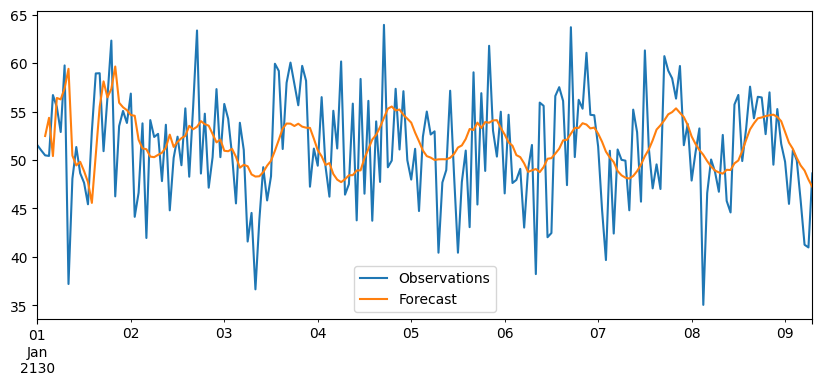

In [54]:
result = model.fit(data, mem=1)

fig, ax = plt.subplots(figsize=(10, 4))
data.plot(y="energy", ax=ax)
result["mean"].shift(1).plot(ax=ax)
plt.legend(["Observations", "Forecast"])
plt.show()


### Multivariate target

The recursive ridge workflow also supports multivariate targets.


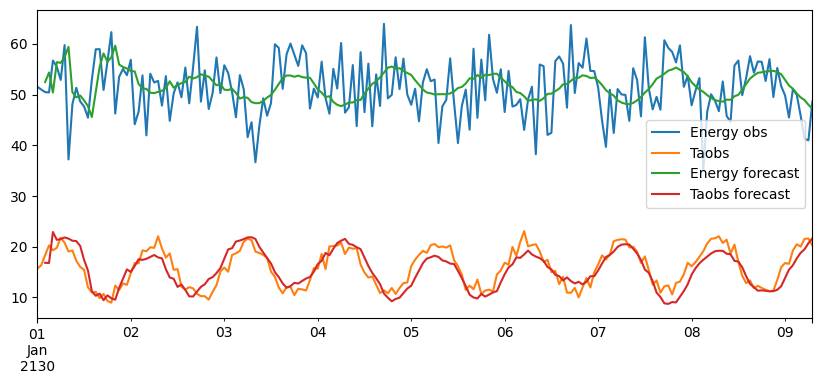

In [55]:
target = DEFAULT_SOURCE[["energy", "Taobs"]]
model_multi = ForecastModel(X, target, horizon=1, track_memory=True, init_K=0.00001)
result_multi = model_multi.fit(data, mem=1)

fig, ax = plt.subplots(figsize=(10, 4))
data.plot(y="energy", ax=ax)
data.plot(y="Taobs", ax=ax)
result_multi["mean"].shift(1).plot(ax=ax)
plt.legend(["Energy obs", "Taobs", "Energy forecast", "Taobs forecast"])
plt.show()


### 3.4 Simulate online updates

To emulate an online setting, data is passed to the model one observation at a time.

Inputs are assumed to have observations along the first axis. For a single observation, this means using a one-row DataFrame such as `data.iloc[[i]]`.


In [56]:
subsets = [data.iloc[[i]] for i in range(len(data))]

model.reset_state()
predictions = []

for s in subsets:
    p = model.update(s, mem=1)["mean"]
    predictions.append(p)

predictions = pd.concat(predictions)

print(np.allclose(result["mean"].to_numpy()[1:], predictions.to_numpy()[1:]))


True


In [57]:
model.update(data, update_predictor=False)


{'mean': Variable                energy
 Horizon                      1
 2130-01-01 00:00:00  48.268914
 2130-01-01 01:00:00  49.295261
 2130-01-01 02:00:00  49.162442
 2130-01-01 03:00:00  48.522786
 2130-01-01 04:00:00  48.629899
 ...                        ...
 2130-01-09 03:00:00  49.251509
 2130-01-09 04:00:00  48.748764
 2130-01-09 05:00:00  47.893458
 2130-01-09 06:00:00  47.248101
 2130-01-09 07:00:00  47.234056
 
 [200 rows x 1 columns],
 'cov': Variable            (energy, energy)
 Horizon                            1
 2130-01-01 00:00:00        29.754629
 2130-01-01 01:00:00        29.601694
 2130-01-01 02:00:00        29.617114
 2130-01-01 03:00:00        29.705725
 2130-01-01 04:00:00        29.691394
 ...                              ...
 2130-01-09 03:00:00        29.619501
 2130-01-09 04:00:00        29.676239
 2130-01-09 05:00:00        29.818046
 2130-01-09 06:00:00        29.953284
 2130-01-09 07:00:00        29.954957
 
 [200 rows x 1 columns]}

## Multi-horizon forecasting


A simple approach for making multi-horizon predictions is to make a new model for each. Here we create a second model for the 2-hour-ahead forecast.


In [58]:
ta2 = Subset(DEFAULT_SOURCE, "Ta", horizons=(2,))
lp_Ta2 = LowPass(ta2, alpha=0.8)
X2 = (const, lp_Taobs, lp_Ta2)

model_2h = ForecastModel(X2, energy, horizon=2, track_memory=True, init_K=0.00001)

ref_1h = model.fit(data, mem=1)
ref_2h = model_2h.fit(data, mem=1)


### Model ensembles
In many cases, such two models may share many basic input features, and we may benefit from evaluating them in a single pass without recomputing known values. The `Combine` transformation evaluates all inputs and returns a `dict` with the results.

In [59]:
models = Combine(model, model_2h)
result = models(data, mem=1)

result_model_1h = result[model]
result_model_2h = result[model_2h]

result_model_1h["mean"].head(), result_model_2h["mean"].head()


(Variable                energy
 Horizon                      1
 2130-01-01 00:00:00        NaN
 2130-01-01 01:00:00  52.477670
 2130-01-01 02:00:00  54.352502
 2130-01-01 03:00:00  50.405863
 2130-01-01 04:00:00  56.399926,
 Variable                energy
 Horizon                      2
 2130-01-01 00:00:00        NaN
 2130-01-01 01:00:00        NaN
 2130-01-01 02:00:00  53.309106
 2130-01-01 03:00:00  43.747420
 2130-01-01 04:00:00  19.704705)

### The `ForecastEnsemble`

`ForecastEnsemble` creates multiple models and splits forecast-matrix data by horizon. The `input_horizons` argument (also supported by `ForecastModel`) determines which of the input features to use based on the horizon. If `auto` is selected, the model will use horizons $(0,h)$ where $h$ is the forecast horizons of the given model.


In [60]:
ta_all = DEFAULT_SOURCE[["Ta"]]
lp_Ta_all = LowPass(ta_all, alpha=0.8)
Xall = (const, lp_Taobs, lp_Ta_all)

horizon_models = ForecastEnsemble(
    Xall,
    energy,
    horizons=(1, 2),
    input_horizons="auto",
    track_memory=True,
    init_K=0.00001,
)

horizon_result = horizon_models.fit(data, mem=1)


Just as before, we can also make updates in an online manner,

In [61]:
horizon_models.reset_state()
predictions = []

for s in subsets:
    p = horizon_models.update(s, mem=1)["mean"]
    predictions.append(p)

predictions = pd.concat(predictions, axis=0)

print(np.allclose(horizon_result["mean"].to_numpy()[2:], predictions.to_numpy()[2:]))


True


## Hyperparameter optimization
Model hyperparameters, including transform parameters and predictor settings, can be optimized by scoring the fitted model. To enable this, prediction transformations (such as `RRR` and `ForecastModel`) may expose a "score mode". For these models, setting score mode will add an extra evaluation step in the transformation, which includes a "score" in the output.


Say for instance a slow trend is added to the data.


In [62]:
trend_data = data.copy()
trend_data[("energy", 0)] += 0.1 * np.arange(len(trend_data))

The optimal low-pass filter parameter may depend on the data, and we thus estimate it in an outer loop,

In [63]:


model.set_score_mode()

def obj(x):
    alpha, mem = x
    lp_Taobs.alpha = alpha
    lp_Ta.alpha = alpha
    return model.fit(trend_data, mem=mem)["score"]

res = minimize(obj, x0=[0.5, 0.5], bounds=[(0, 1), (0, 1)], method="Nelder-Mead")
print(res)


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 5.700395088827669
             x: [ 3.377e-01  9.324e-01]
           nit: 63
          nfev: 120
 final_simplex: (array([[ 3.377e-01,  9.324e-01],
                       [ 3.378e-01,  9.324e-01],
                       [ 3.377e-01,  9.324e-01]]), array([ 5.700e+00,  5.700e+00,  5.700e+00]))


The `ForecastEnsemble` enables a similar approach,

In [64]:
horizon_models.set_score_mode()

def obj_horizon(x):
    alpha, mem = x
    lp_Taobs.alpha = alpha
    lp_Ta_all.alpha = alpha
    result = horizon_models.fit(trend_data, mem=mem)
    return np.mean(list(result["score"].values()))

res_horizon = minimize(
    obj_horizon,
    x0=[0.5, 0.5],
    bounds=[(0, 1), (0, 1)],
    method="Nelder-Mead",
)
print(res_horizon)


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 6.1434452045205035
             x: [ 4.374e-01  9.250e-01]
           nit: 61
          nfev: 116
 final_simplex: (array([[ 4.374e-01,  9.250e-01],
                       [ 4.375e-01,  9.250e-01],
                       [ 4.375e-01,  9.250e-01]]), array([ 6.143e+00,  6.143e+00,  6.143e+00]))


## Custom transforms and predictors
...